# W1 - Statistical Analysis: Olist Payment & Delivery Data

## D1: Descriptive Statistics & Distributions
- Dataset: olist_raw.order_payments (103,886 records)
- Key finding: Payment value is heavily right-skewed (skewness=9.25)
- Mean (154 BRL) overstates typical order value by 54% vs median (100 BRL)
- Log transformation normalises distribution — essential before ML modelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

conn = psycopg2.connect(
    host="olist-pipeline.cg1gusiqwbyb.us-east-1.rds.amazonaws.com",
    port=5432,
    database="postgres",
    user="postgres",
    password="Admin1234!"
)

# Verify connection + check available tables
query = """
    SELECT table_schema, table_name 
    FROM information_schema.tables 
    WHERE table_schema NOT IN ('information_schema', 'pg_catalog')
    ORDER BY table_schema, table_name
"""

df_tables = pd.read_sql(query, conn)
print(df_tables)

C:\Users\deepe\AppData\Local\Temp\ipykernel_6252\2677839359.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql(query, conn)


   table_schema                    table_name
0    crypto_dev                     dim_coins
1    crypto_dev              fct_daily_prices
2    crypto_dev          fct_market_dominance
3    crypto_dev           fct_volume_analysis
4    crypto_dev               stg_coin_prices
5    crypto_raw                  daily_prices
6     olist_dev                 dim_customers
7     olist_dev                      dim_date
8     olist_dev                  dim_products
9     olist_dev   fct_bad_reviews_by_category
10    olist_dev      fct_category_performance
11    olist_dev                    fct_orders
12    olist_dev          fct_payment_analysis
13    olist_dev               stg_order_items
14    olist_dev            stg_order_payments
15    olist_dev             stg_order_reviews
16    olist_dev                    stg_orders
17    olist_dev                  stg_products
18    olist_raw                     customers
19    olist_raw                   geolocation
20    olist_raw                   

In [13]:
import sys
print(sys.executable)

c:\Python\python.exe


In [2]:
# Pull payment data for distribution analysis
df_payments = pd.read_sql("""
    SELECT order_id, payment_type, payment_value
    FROM olist_raw.order_payments
""", conn)

# Pull orders data for delivery analysis later
df_orders = pd.read_sql("""
    SELECT order_id, order_status,
           order_purchase_timestamp,
           order_delivered_customer_date,
           order_estimated_delivery_date
    FROM olist_raw.orders
    WHERE order_status = 'delivered'
""", conn)

print("Payments shape:", df_payments.shape)
print("Orders shape:", df_orders.shape)
print(df_payments.head())

C:\Users\deepe\AppData\Local\Temp\ipykernel_6252\2387124533.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_payments = pd.read_sql("""
C:\Users\deepe\AppData\Local\Temp\ipykernel_6252\2387124533.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_orders = pd.read_sql("""


Payments shape: (103886, 3)
Orders shape: (96478, 5)
                           order_id payment_type  payment_value
0  b81ef226f3fe1789b1e8b2acac839d17  credit_card          99.33
1  a9810da82917af2d9aefd1278f1dcfa0  credit_card          24.39
2  25e8ea4e93396b6fa0d3dd708e76c1bd  credit_card          65.71
3  ba78997921bbcdc1373bb41e913ab953  credit_card         107.78
4  42fdf880ba16b47b59251dd489d4441a  credit_card         128.45


In [6]:
df_payments.head()

,order_id,payment_type,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,credit_card,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,credit_card,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,credit_card,65.71
3,ba78997921bbcdc1373bb41e913ab953,credit_card,107.78
4,42fdf880ba16b47b59251dd489d4441a,credit_card,128.45


In [3]:
df_orders.head()

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,02-10-2017 10:56,10-10-2017 21:25,18-10-2017 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,24-07-2018 20:41,07-08-2018 15:27,13-08-2018 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,08-08-2018 08:38,17-08-2018 18:06,04-09-2018 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,18-11-2017 19:28,02-12-2017 00:28,15-12-2017 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,13-02-2018 21:18,16-02-2018 18:17,26-02-2018 00:00


In [15]:
print("=== Payment Value Stats ===")
print(df_payments['payment_value'].describe())
print(f"\nSkewness: {df_payments['payment_value'].skew():.3f}")
print(f"Kurtosis: {df_payments['payment_value'].kurtosis():.3f}")
print(f"Missing Values: {df_payments['payment_value'].isnull().sum()}")

=== Payment Value Stats ===
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Skewness: 9.254
Kurtosis: 241.828
Missing Values: 0


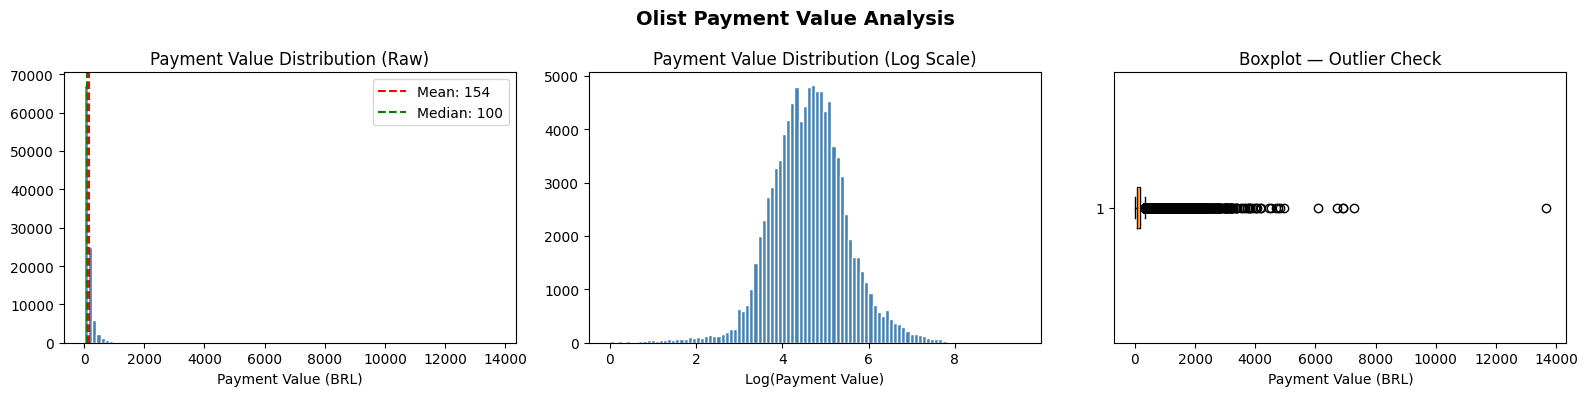

In [16]:
fig, axes = plt.subplots(1,3, figsize= (16, 4))

axes[0].hist(df_payments['payment_value'], bins = 100, color = 'steelblue', edgecolor = 'white')
axes[0].set_title('Payment Value Distribution (Raw)')
axes[0].set_xlabel('Payment Value (BRL)')
axes[0].axvline(df_payments['payment_value'].mean(), color='red', linestyle='--', label=f"Mean: {df_payments['payment_value'].mean():.0f}")
axes[0].axvline(df_payments['payment_value'].median(), color='green', linestyle='--', label=f"Median: {df_payments['payment_value'].median():.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df_payments['payment_value']), bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Payment Value Distribution (Log Scale)')
axes[1].set_xlabel('Log(Payment Value)')

axes[2].boxplot(df_payments['payment_value'], vert=False)
axes[2].set_title('Boxplot — Outlier Check')
axes[2].set_xlabel('Payment Value (BRL)')

plt.suptitle('Olist Payment Value Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('payment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## D2: Central Limit Theorem Simulation
- Simulated 1000 samples at n=5, n=30, n=100 from skewed payment data
- CLT confirmed: sampling distribution approaches normal as n increases
- Standard Error: 135 (n=5) → 40 (n=30) → 23 (n=100)
- Key insight: hypothesis tests are valid on this data despite skewness (n >> 30)

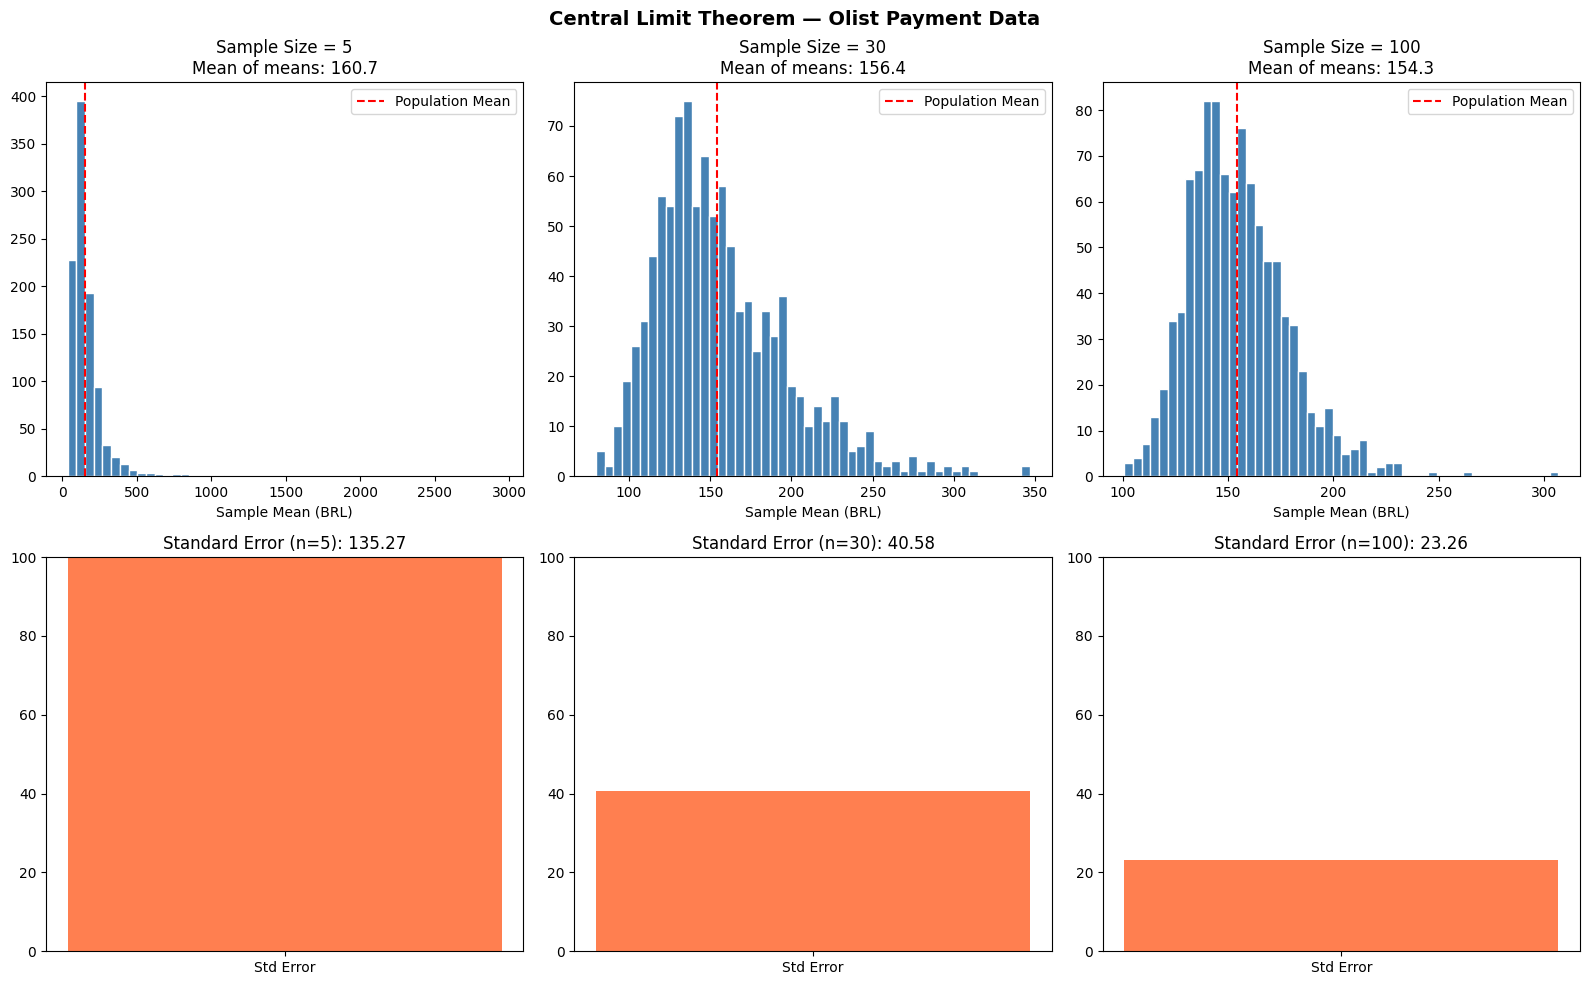

In [11]:
import random

population = df_payments['payment_value'].dropna().values

sample_sizes = [5, 30, 100]
n_samples = 1000

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, sample_size in enumerate(sample_sizes):
    # Draw 1000 random samples of given size, compute mean of each
    sample_means = [
        np.mean(random.choices(population, k=sample_size)) 
        for _ in range(n_samples)
    ]
    
    # Top row — histogram of sample means
    axes[0][idx].hist(sample_means, bins=50, color='steelblue', edgecolor='white')
    axes[0][idx].set_title(f'Sample Size = {sample_size}\nMean of means: {np.mean(sample_means):.1f}')
    axes[0][idx].set_xlabel('Sample Mean (BRL)')
    axes[0][idx].axvline(np.mean(population), color='red', linestyle='--', label='Population Mean')
    axes[0][idx].legend()
    
    # Bottom row — how spread out are the sample means (Standard Error)
    std_error = np.std(sample_means)
    axes[1][idx].bar(['Std Error'], [std_error], color='coral')
    axes[1][idx].set_title(f'Standard Error (n={sample_size}): {std_error:.2f}')
    axes[1][idx].set_ylim(0, 100)

plt.suptitle('Central Limit Theorem — Olist Payment Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clt_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

## D3: Hypothesis Testing — T-Test on Delivery Times
- H0: No difference in delivery time between high and low value orders
- Split 96,469 orders at median payment value (105.28 BRL)
- High value mean: 12.96 days | Low value mean: 11.23 days
- t-statistic: 28.35 | p-value: ≈0.000
- Decision: Reject H0 — difference is statistically significant
- Business insight: High value orders (electronics, furniture) take 1.74 days
  longer likely due to bulk size and limited seller coverage

In [5]:
# Calculate actual delivery time in days
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'], format='%d-%m-%Y %H:%M')
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'], format='%d-%m-%Y %H:%M')

df_orders['delivery_days'] = (
    df_orders['order_delivered_customer_date'] - 
    df_orders['order_purchase_timestamp']
).dt.days

# Quick sanity check
print("Delivery days stats:")
print(df_orders['delivery_days'].describe())
print(f"\nNegative delivery days: {(df_orders['delivery_days'] < 0).sum()}")
print(f"Nulls: {df_orders['delivery_days'].isnull().sum()}")

Delivery days stats:
count    96470.000000
mean        12.094029
std          9.551435
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

Negative delivery days: 0
Nulls: 8


In [ ]:
# drop nulls
df_orders_clean = df_orders.dropna(subset=['delivery_days'])

# aggregate payments to order level (some orders have multiple payments)
df_pay_agg = df_payments.groupby('order_id')['payment_value'].sum().reset_index()

# Merge delivery days with payment value
df_merged = pd.merge(df_orders_clean, df_pay_agg, on='order_id', how = 'inner')
print("Merged shape:", df_merged.shape)

# split into high vs low using median as threshold
median_payment = df_merged['payment_value'].median()
print(f"Median Payment Value: {median_payment} BRL")

# we need the delivery days of those high value payments
df_high = df_merged[df_merged['payment_value'] > median_payment]['delivery_days']
# we need the delivery days of those low value payments
df_low = df_merged[df_merged['payment_value'] <= median_payment]['delivery_days']

print(f"\nHigh value orders: {len(df_high)}")  # contains number of HVO
print(f"Low value orders: {len(df_low)}")   # contains number of LVO 
print(f"\nHigh value mean delivery: {df_high.mean():.2f} days")  # mean of delivery days of HVO
print(f"Low value mean delivery: {df_low.mean():.2f} days")   # mean of delivery days of LVO


Merged shape: (96469, 7)
Median Payment Value: 105.28 BRL

High value orders: 48175
Low value orders: 48294

High value mean delivery: 12.96 days
Low value mean delivery: 11.23 days


In [11]:
from scipy import stats

# Two-sample independent t-test
t_stat, p_value = stats.ttest_ind(df_high, df_low)

print("=== Two-Sample T-Test Results ===")
print(f"H0: Mean delivery time is equal for high and low value orders")
print(f"H1: Mean delivery time is NOT equal for high and low value orders")
print(f"\nHigh value mean: {df_high.mean():.2f} days")
print(f"Low value mean:  {df_low.mean():.2f} days")
print(f"Difference:      {df_high.mean() - df_low.mean():.2f} days")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.10f}")
print(f"\nSignificance level (α): 0.05")
if p_value < 0.05:
    print("Decision: REJECT H0 ✓")
    print("Finding: Statistically significant difference in delivery times")
else:
    print("Decision: FAIL TO REJECT H0")
    print("Finding: No statistically significant difference")

=== Two-Sample T-Test Results ===
H0: Mean delivery time is equal for high and low value orders
H1: Mean delivery time is NOT equal for high and low value orders

High value mean: 12.96 days
Low value mean:  11.23 days
Difference:      1.74 days

t-statistic: 28.3466
p-value:     0.0000000000

Significance level (α): 0.05
Decision: REJECT H0 ✓
Finding: Statistically significant difference in delivery times


C:\Users\deepe\AppData\Local\Temp\ipykernel_26080\2784468212.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_high, df_low], labels=['High Value', 'Low Value'])


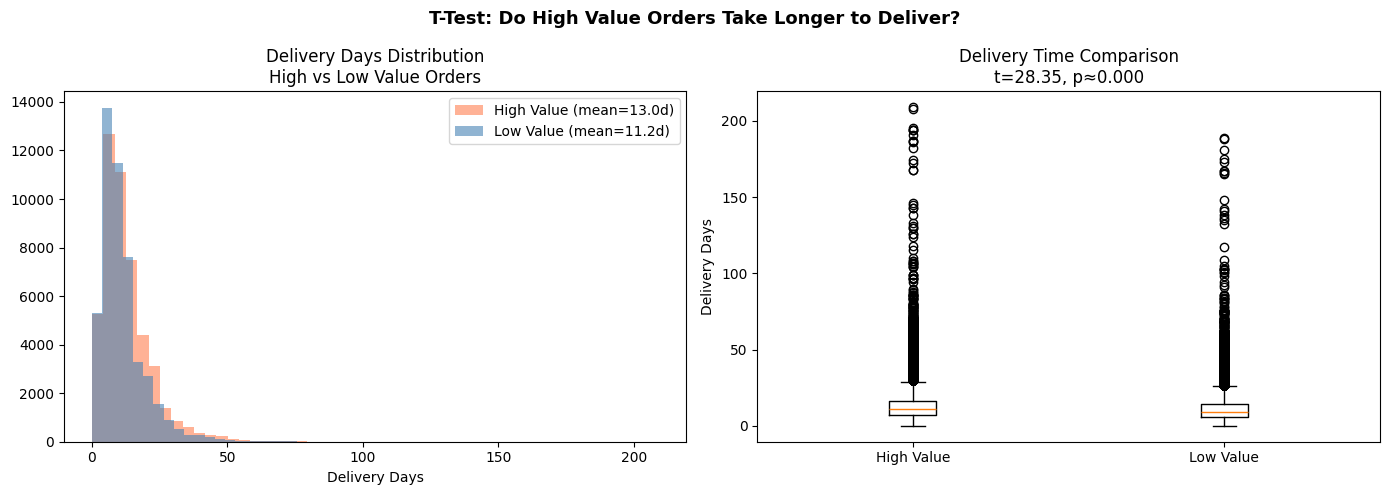

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of delivery days for both groups
axes[0].hist(df_high, bins=50, alpha=0.6, color='coral', label=f'High Value (mean={df_high.mean():.1f}d)')
axes[0].hist(df_low, bins=50, alpha=0.6, color='steelblue', label=f'Low Value (mean={df_low.mean():.1f}d)')
axes[0].set_title('Delivery Days Distribution\nHigh vs Low Value Orders')
axes[0].set_xlabel('Delivery Days')
axes[0].legend()

# Boxplot comparison
axes[1].boxplot([df_high, df_low], labels=['High Value', 'Low Value'])
axes[1].set_title(f'Delivery Time Comparison\nt={t_stat:.2f}, p≈0.000')
axes[1].set_ylabel('Delivery Days')

plt.suptitle('T-Test: Do High Value Orders Take Longer to Deliver?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ttest_delivery.png', dpi=150, bbox_inches='tight')
plt.show()

## D4: Chi-Square Test — Category vs Review Score
- Tested independence between product category and review score
- Dataset: 71,554 orders across top 10 categories
- Chi-square statistic: 211.86 | Degrees of freedom: 9 | p-value: ≈0.000
- Decision: Reject H0 — category significantly influences review scores
- Key finding: moveis_decoracao worst (19.5% bad rate) vs beleza_saude 
  best (13.7%) — 6pp gap driven by shipping complexity of bulky items

In [3]:
query = """
    Select 
    oi.order_id, p.product_category_name, r.review_score
    from olist_raw.order_items oi
    join olist_raw.products p on oi.product_id = p.product_id
    join olist_raw.order_reviews r on oi.order_id = r.order_id
    where p.product_category_name is not null
    and r.review_score is not null """


df_reviews = pd.read_sql(query,conn)
print("Shape:", df_reviews.shape)
print("\nReview score distribution:")
print(df_reviews['review_score'].value_counts().sort_index())

C:\Users\deepe\AppData\Local\Temp\ipykernel_6252\2132073582.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_reviews = pd.read_sql(query,conn)


Shape: (110774, 3)

Review score distribution:
review_score
1    13945
2     3811
3     9322
4    21014
5    62682
Name: count, dtype: int64


In [4]:
print(f"\nUnique categories: {df_reviews['product_category_name'].nunique()}")


Unique categories: 73


In [5]:
top_10_categories = df_reviews['product_category_name'].value_counts().head(10).index
df_top = df_reviews[df_reviews['product_category_name'].isin(top_10_categories)].copy()

print("Top 10 categories shape: ", df_top.shape)
print(df_reviews['product_category_name'].value_counts().head(10))

# Step 3 — Create binary review label
df_top['review_label'] = df_top['review_score'].apply(
    lambda x: 'bad' if x <= 2 else 'good'
)

print("\nReview label distribution:")
print(df_top['review_label'].value_counts())


contingency_table = pd.crosstab(
    df_top['product_category_name'], 
    df_top['review_label'])

print("\nContingency Table:")
print(contingency_table)

Top 10 categories shape:  (71554, 3)
product_category_name
cama_mesa_banho           11137
beleza_saude               9645
esporte_lazer              8640
moveis_decoracao           8331
informatica_acessorios     7849
utilidades_domesticas      6943
relogios_presentes         5950
telefonia                  4517
ferramentas_jardim         4329
automotivo                 4213
Name: count, dtype: int64

Review label distribution:
review_label
good    59626
bad     11928
Name: count, dtype: int64

Contingency Table:
review_label             bad  good
product_category_name             
automotivo               643  3570
beleza_saude            1321  8324
cama_mesa_banho         2112  9025
esporte_lazer           1260  7380
ferramentas_jardim       696  3633
informatica_acessorios  1461  6388
moveis_decoracao        1621  6710
relogios_presentes       967  4983
telefonia                761  3756
utilidades_domesticas   1086  5857


In [6]:
from scipy.stats import chi2_contingency

# Run chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("=== Chi-Square Test Results ===")
print(f"H0: Product category and review score are independent")
print(f"H1: Product category and review score are NOT independent")
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.10f}")
print(f"\nSignificance level (α): 0.05")
if p_value < 0.05:
    print("Decision: REJECT H0 ✓")
    print("Finding: Product category significantly influences review scores")
else:
    print("Decision: FAIL TO REJECT H0")
    print("Finding: No significant relationship found")

# Bad review rate per category
contingency_table['bad_rate'] = (
    contingency_table['bad'] / 
    (contingency_table['bad'] + contingency_table['good']) * 100
).round(2)
print("\nBad review rate per category:")
print(contingency_table.sort_values('bad_rate', ascending=False))

=== Chi-Square Test Results ===
H0: Product category and review score are independent
H1: Product category and review score are NOT independent

Chi-square statistic: 211.8575
Degrees of freedom:   9
p-value:              0.0000000000

Significance level (α): 0.05
Decision: REJECT H0 ✓
Finding: Product category significantly influences review scores

Bad review rate per category:
review_label             bad  good  bad_rate
product_category_name                       
moveis_decoracao        1621  6710     19.46
cama_mesa_banho         2112  9025     18.96
informatica_acessorios  1461  6388     18.61
telefonia                761  3756     16.85
relogios_presentes       967  4983     16.25
ferramentas_jardim       696  3633     16.08
utilidades_domesticas   1086  5857     15.64
automotivo               643  3570     15.26
esporte_lazer           1260  7380     14.58
beleza_saude            1321  8324     13.70
